# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [39]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [40]:
# Inspect the shapes of the datasets

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)



X_train shape: (60000, 28, 28)
y_train shape: (60000, 10)


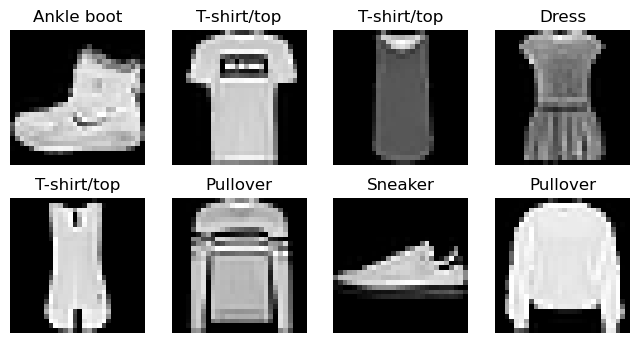

In [41]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?


In the data, the images matches the labels but the quality of the images is blurry.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [42]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model

# You can use `model.add(<layer>)` to add layers to the model

# Compile the model using `model.compile()`

# Train the model with `model.fit()`

# Evaluate the model with `model.evaluate()`


model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10))

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Train the model
model.fit(X_train, y_train, epochs=5, validation_split=0.1, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

/opt/miniconda3/envs/myenv312/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - accuracy: 0.1815 - loss: 9.0916 - val_accuracy: 0.0827 - val_loss: 10.3399
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step - accuracy: 0.0999 - loss: 10.5756 - val_accuracy: 0.2345 - val_loss: 10.1266
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - accuracy: 0.2215 - loss: 10.3134 - val_accuracy: 0.1888 - val_loss: 10.6648
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - accuracy: 0.1885 - loss: 10.4742 - val_accuracy: 0.2003 - val_loss: 10.4365
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - accuracy: 0.2098 - loss: 10.5104 - val_accuracy: 0.2148 - val_loss: 10.5520
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - accuracy: 0.2123 - loss: 10.5789
Test Loss: 10.6154, Test Accuracy: 0.2166


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?


The baseline linear model achieved a test accuracy of approximately 22% on the dataset, which is relatively low but expected given the simplicity of the model. Since this model treats each 28x28 image as a flat vector without capturing any spatial structure, it cannot effectively learn complex features such as edges, textures, or shapes that are essential for distinguishing between similar clothing items. This limitation results in poor classification performance compared to more sophisticated models like convolutional neural networks.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [43]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=5, validation_split=0.1, batch_size=32)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8114 - loss: 0.5411 - val_accuracy: 0.8842 - val_loss: 0.3348
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8953 - loss: 0.2945 - val_accuracy: 0.8873 - val_loss: 0.3177
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9083 - loss: 0.2558 - val_accuracy: 0.8925 - val_loss: 0.2978
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9196 - loss: 0.2218 - val_accuracy: 0.8997 - val_loss: 0.2827
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9288 - loss: 0.2019 - val_accuracy: 0.9037 - val_loss: 0.2850
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8976 - loss: 0.3044
Test Loss: 0.3038, Test Accuracy: 0.8972


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?


Yes, the CNN model performed better than the baseline linear model. The CNN achieved about 90% test accuracy, which is a huge improvement over the baseline model’s 22% accuracy. Unlike the baseline model that flattened images into vectors and ignored spatial relationships, the CNN leverages convolutional layers to learn local patterns like edges, textures, and shapes in the image.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [44]:
# A. Test Hyperparameters
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout

def build_model(num_filters=32, use_dropout=False, dropout_rate=0.5):
    model = Sequential()
    model.add(Conv2D(num_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    if use_dropout:
        model.add(Dropout(dropout_rate))
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

filter_options = [32,64,128]
dropout_options = [False, True]

results = []

for filters in filter_options:
    for dropout in dropout_options:
        print(f"Training model with {filters} filters and dropout={dropout}")
        model = build_model(num_filters=filters, use_dropout=dropout)
        


        # Train the model
        model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)
        
        # Evaluate on test set
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
        
        # Store results
        results.append({
            'num_filters': filters,
            'use_dropout': dropout,
            'test_accuracy': accuracy,
            'test_loss': loss
        })
        
        print(f"Test accuracy: {accuracy:.4f}, Test loss: {loss:.4f}")

Training model with 32 filters and dropout=False
Test accuracy: 0.9011, Test loss: 0.2882
Training model with 32 filters and dropout=True
Test accuracy: 0.8948, Test loss: 0.2951
Training model with 64 filters and dropout=False
Test accuracy: 0.9014, Test loss: 0.2946
Training model with 64 filters and dropout=True
Test accuracy: 0.8937, Test loss: 0.3009
Training model with 128 filters and dropout=False
Test accuracy: 0.8987, Test loss: 0.3052
Training model with 128 filters and dropout=True
Test accuracy: 0.8996, Test loss: 0.2869


   num_filters  use_dropout  test_accuracy  test_loss
0           32        False         0.9011   0.288189
1           32         True         0.8948   0.295081
2           64        False         0.9014   0.294641
3           64         True         0.8937   0.300874
4          128        False         0.8987   0.305222
5          128         True         0.8996   0.286882


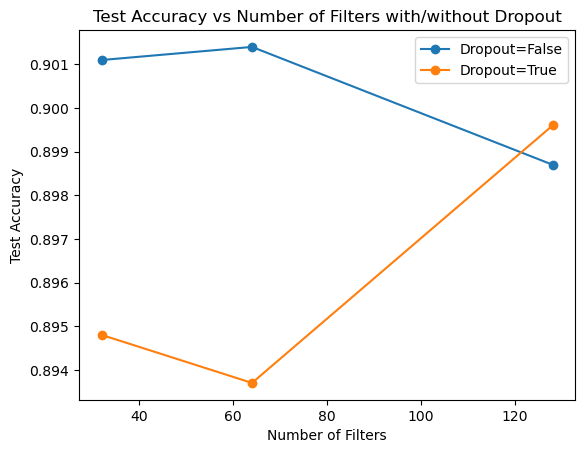

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(results)

# Print summary table
print(df_results)

# Plot test accuracy for each configuration
fig, ax = plt.subplots()

for dropout in dropout_options:
    subset = df_results[df_results['use_dropout'] == dropout]
    ax.plot(subset['num_filters'], subset['test_accuracy'], marker='o', label=f'Dropout={dropout}')

ax.set_xlabel('Number of Filters')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy vs Number of Filters with/without Dropout')
ax.legend()
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?


In this experiment, I tested the number of convolutional filters and the presence or absence of dropout as a regularization technique. Increasing the number of filters from 32 to 64 slightly improved test accuracy, indicating that more filters helped the model learn richer feature representations. However, increasing filters further to 128 did not lead to accuracy gains, suggesting diminishing returns with model complexity.
For smaller and medium-sized models with 32 and 64 filters, adding dropout slightly reduced test accuracy, likely because these models were not complex enough to overfit significantly. For the larger model with 128 filters, dropout improved test accuracy and reduced loss, showing its benefit as a regularization technique to prevent overfitting in more complex models. The best-performing configuration was 64 filters without dropout, achieving a test accuracy of 90%.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [46]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

# Define the final model
final_model = Sequential()


# Add convolutional layer with 64 filters
final_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Flatten and output
final_model.add(Flatten())
final_model.add(Dense(10, activation='softmax'))



# Compile the model
final_model.compile(optimizer=Adam(),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train the model
final_model.fit(X_train, y_train,
                epochs=5,
                batch_size=32,
                validation_split=0.1,
                verbose=2)

# Evaluate the final model
final_loss, final_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Loss: {final_loss:.4f}, Final Test Accuracy: {final_accuracy:.4f}")

Epoch 1/5


/opt/miniconda3/envs/myenv312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 - 12s - 7ms/step - accuracy: 0.8605 - loss: 0.3960 - val_accuracy: 0.8858 - val_loss: 0.3275
Epoch 2/5
1688/1688 - 13s - 8ms/step - accuracy: 0.9017 - loss: 0.2754 - val_accuracy: 0.8933 - val_loss: 0.3023
Epoch 3/5
1688/1688 - 14s - 8ms/step - accuracy: 0.9170 - loss: 0.2347 - val_accuracy: 0.8982 - val_loss: 0.2905
Epoch 4/5
1688/1688 - 11s - 7ms/step - accuracy: 0.9254 - loss: 0.2043 - val_accuracy: 0.9053 - val_loss: 0.2832
Epoch 5/5
1688/1688 - 11s - 7ms/step - accuracy: 0.9354 - loss: 0.1790 - val_accuracy: 0.9013 - val_loss: 0.3008
Final Test Loss: 0.3068, Final Test Accuracy: 0.8961


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?


The final model outperformed the baseline linear model but slightly underperformed the initial CNN. This outcome suggests that increasing the number of convolutional filters alone did not significantly improve the model’s ability to learn richer and more diverse feature representations. While more filters can help capture more complex patterns, they may not be sufficient by themselves to enhance classification performance. The results indicate that other architectural factors such as the depth of the network, learning rate or optimizer choice, could play a more important role in boosting model performance. If I had more time, I would experiment with them to improve the model's performance.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.